# Customer Churn Prediction — Telco Dataset
### End-to-End Machine Learning Project

**Author:** *Abdoul Razak*
**Dataset:** IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)

---


## 1. Business Problem Statement

Customer churn — the rate at which customers stop doing business with a company — is one of the
most significant threats to revenue in subscription-based industries such as telecommunications.
The telecom sector typically experiences an annual churn rate of **15–25%**, and acquiring a new
customer can cost **up to 5–25x more** than retaining an existing one.

**Business questions this project answers:**
1. Which customers are most likely to churn, and can we predict this in advance?
2. Which factors (contract type, tenure, services subscribed, billing, etc.) drive churn the most?
3. What actions can the business take to reduce churn and protect revenue?

**Dataset overview:** The dataset contains 7,043 customers of a fictional telecom company, with
information on:
- **Demographics:** gender, senior citizen status, partner, dependents
- **Account information:** tenure, contract type, payment method, paperless billing, monthly &
  total charges
- **Services subscribed:** phone, multiple lines, internet, online security/backup, device
  protection, tech support, streaming TV/movies
- **Target variable:** `Churn` (Yes / No)

## 2. Project Objectives

- Perform thorough exploratory data analysis (EDA) to understand churn drivers.
- Engineer features suitable for machine learning models.
- Benchmark a wide range of classical ML algorithms for churn classification.
- Address the class imbalance present in the target variable.
- Tune the best-performing model and evaluate a deep-learning alternative (AutoKeras) for comparison.
- Select a final model based on business-relevant metrics (recall on the churn class is prioritized,
  since the cost of *missing* a churner is typically higher than a false alarm) and translate the
  results into actionable business recommendations.

## 3. Project Workflow

`Data Loading → Cleaning → EDA → Feature Engineering → Train/Test Split → Baseline Modeling →
Class-Imbalance Handling → Feature Importance → Hyperparameter Tuning → Deep Learning Benchmark →
Final Evaluation → Business Recommendations`


## 4. Setup & Environment

This notebook is designed to run in **Google Colab** with the dataset stored on Google Drive.
Run the cell below to mount your Drive, then run the install cell (first run only — installs
libraries not preinstalled in Colab).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install libraries not preinstalled in Colab (first run only)
!pip install -q xgboost catboost imbalanced-learn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.2 MB/s eta 0:00:00


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 1234
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
PALETTE = 'Blues'

## 5. Load Data

Update `DATA_PATH` below if your folder structure on Drive differs.


In [4]:
DATA_PATH = "/content/drive/MyDrive/Data Science & AI Projects/Project 2. Customer Churn Prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Data Understanding

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


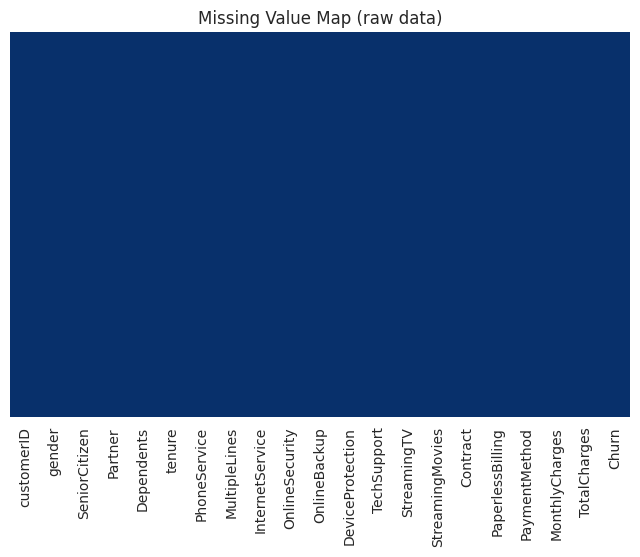

In [7]:
# Missing value check
print(df.isnull().sum())
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Blues_r')
plt.title('Missing Value Map (raw data)')
plt.show()

In [8]:
# Duplicate rows check
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


## 7. Data Cleaning

Observations from the raw data:
- `TotalCharges` is stored as text and contains blank strings for customers with 0 tenure — these
  need to be converted to numeric (`NaN`) and handled.
- `customerID` is a unique identifier with no predictive value and should be dropped.
- Several service columns use `"No internet service"` / `"No phone service"` as a category, which
  is functionally equivalent to `"No"` for modeling purposes.


In [9]:
# TotalCharges -> numeric (blank strings become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Rows with missing TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# These are new customers with 0 tenure -- safe to drop (small fraction of the data)
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Shape after dropping missing TotalCharges: {df.shape}")

Rows with missing TotalCharges after conversion: 11
Shape after dropping missing TotalCharges: (7032, 21)


In [10]:
# Drop the unique identifier column
df = df.drop(columns=['customerID'])

def show_categorical_levels(frame):
    for col in frame.select_dtypes(include='object').columns:
        print(f"{col}: {frame[col].unique()}")

print("Before consolidation:")
show_categorical_levels(df)

Before consolidation:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [11]:
# Consolidate "No internet/phone service" into "No"
df = df.replace('No internet service', 'No')
df = df.replace('No phone service', 'No')

print("After consolidation:")
show_categorical_levels(df)

After consolidation:
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


## 8. Exploratory Data Analysis

### 8.1 Target variable — Churn distribution


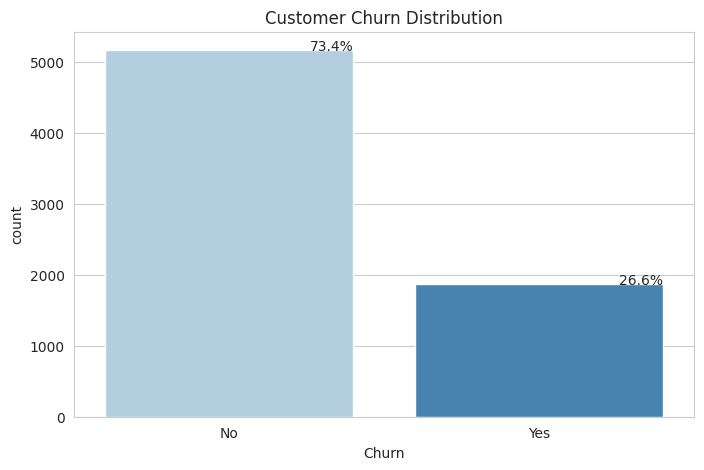

Overall churn rate: 26.6%


In [12]:
def annotate_percentages(ax, total):
    for p in ax.patches:
        pct = f"{100 * p.get_height() / total:.1f}%"
        ax.annotate(pct, (p.get_x() + p.get_width(), p.get_height()), ha='right')

ax = sns.countplot(x='Churn', data=df, palette=PALETTE)
annotate_percentages(ax, len(df))
plt.title('Customer Churn Distribution')
plt.show()

churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f"Overall churn rate: {churn_rate:.1f}%")

The dataset is **imbalanced**: roughly a quarter of customers have churned. This will need to
be addressed later — a model that simply predicts "No churn" for everyone would already reach
~73% accuracy while being useless for retention efforts. **Recall on the churn class** is therefore
the key business metric.

### 8.2 Demographics


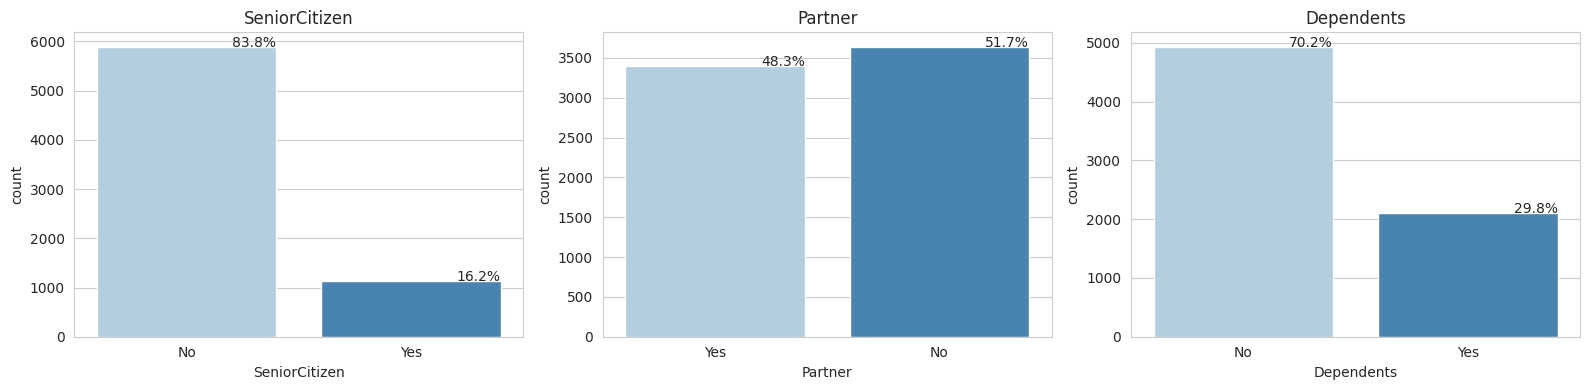

Gender split:
gender
Male      50.5
Female    49.5
Name: proportion, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax_i, col in zip(axes, ['SeniorCitizen', 'Partner', 'Dependents']):
    data_col = df[col].replace({0: 'No', 1: 'Yes'}) if col == 'SeniorCitizen' else df[col]
    ax = sns.countplot(x=data_col, palette=PALETTE, ax=ax_i)
    annotate_percentages(ax, len(df))
    ax.set_title(col)

plt.tight_layout()
plt.show()

print(f"Gender split:\n{(df['gender'].value_counts(normalize=True) * 100).round(1)}")

Senior citizens make up only ~16% of the customer base. Gender is evenly split. About half of
customers have a partner, and ~30% have dependents.

### 8.3 Services subscribed


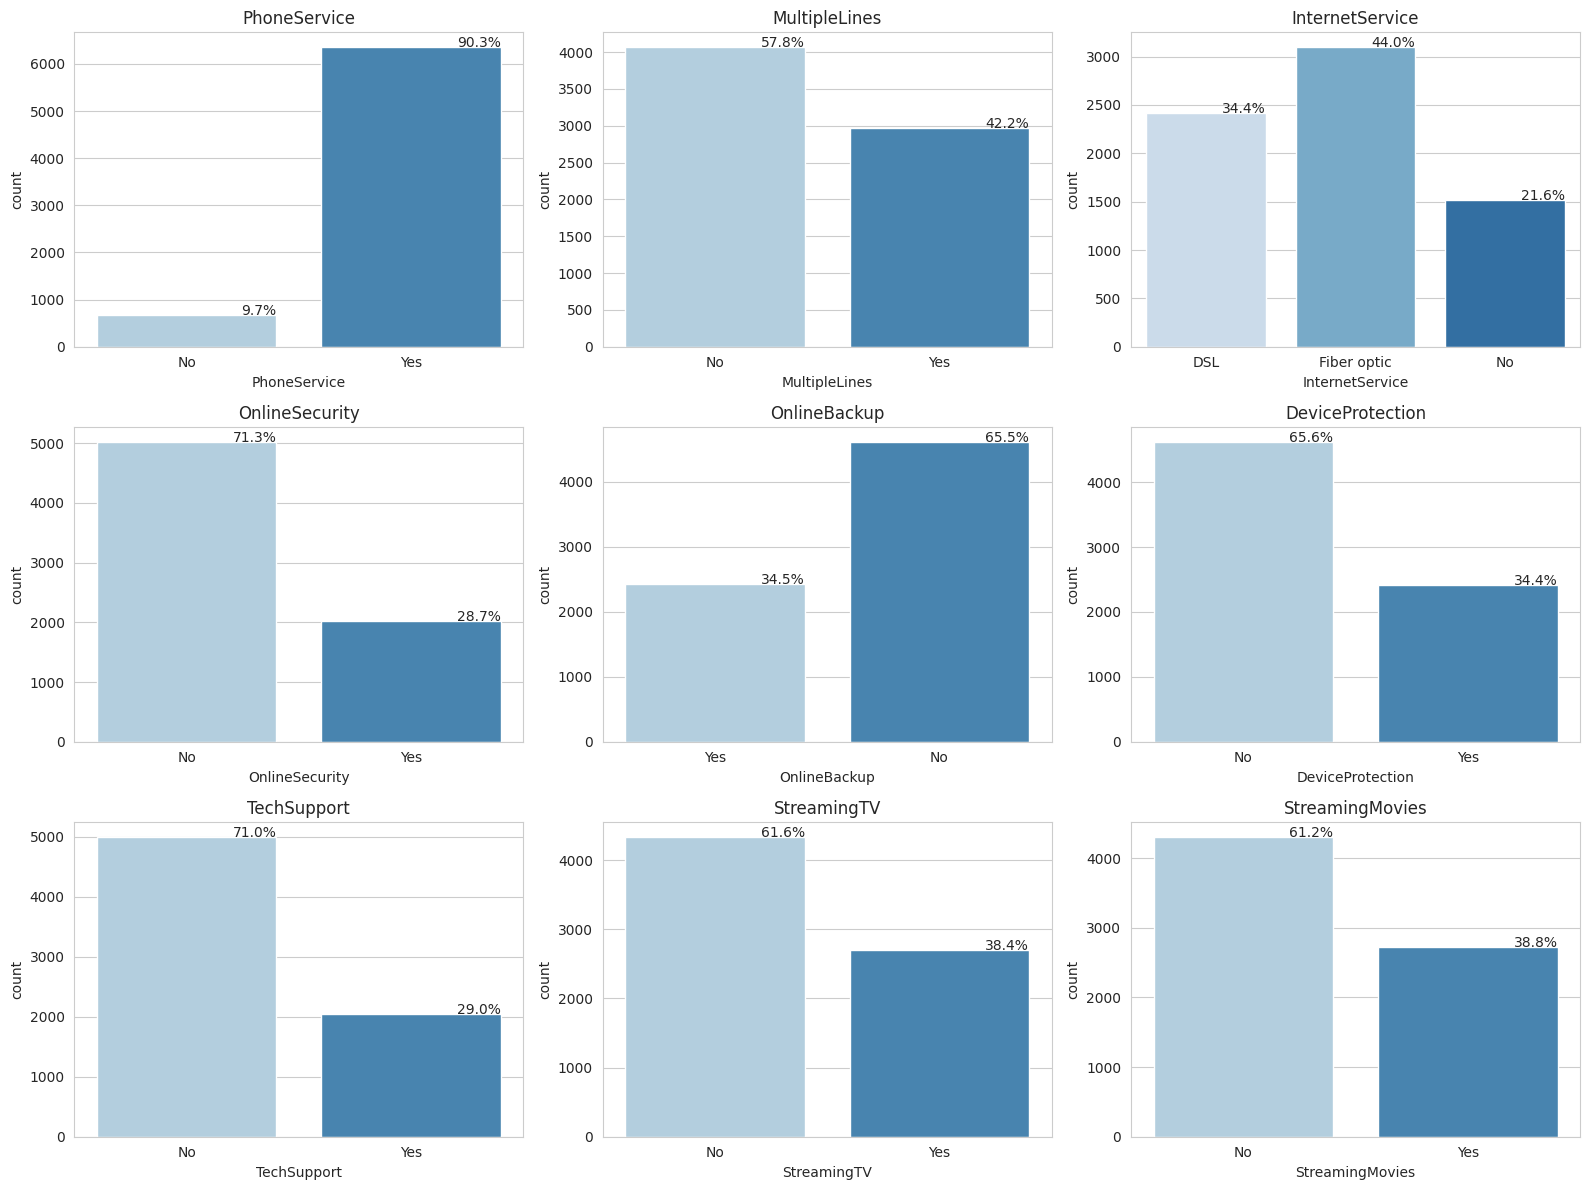

In [14]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), services):
    a = sns.countplot(x=df[col], palette=PALETTE, ax=ax)
    annotate_percentages(a, len(df))
    a.set_title(col)
plt.tight_layout()
plt.show()

### 8.4 Account information — contract, billing, payment

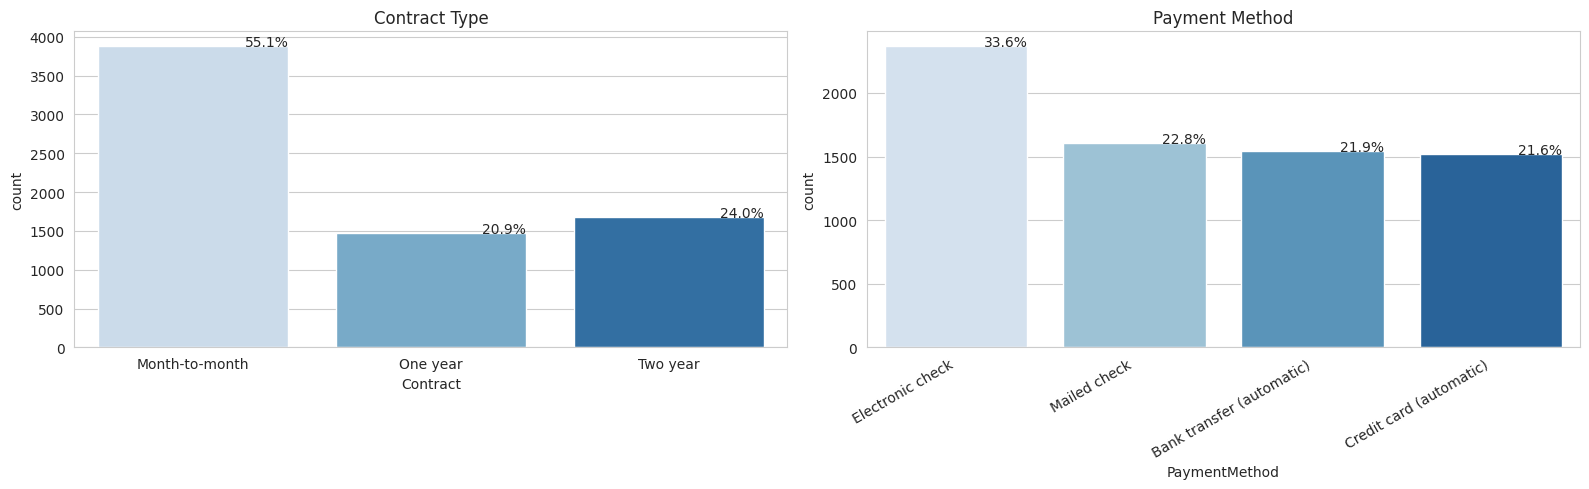

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.countplot(x='Contract', data=df, palette=PALETTE, ax=axes[0])
annotate_percentages(ax, len(df))
axes[0].set_title('Contract Type')

ax = sns.countplot(x='PaymentMethod', data=df, palette=PALETTE, ax=axes[1])
annotate_percentages(ax, len(df))
axes[1].set_title('Payment Method')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

Over half of customers (55%) are on a flexible **month-to-month** contract — this segment,
as we'll see below, drives most of the churn.

### 8.5 Numerical features — tenure, charges, and outliers


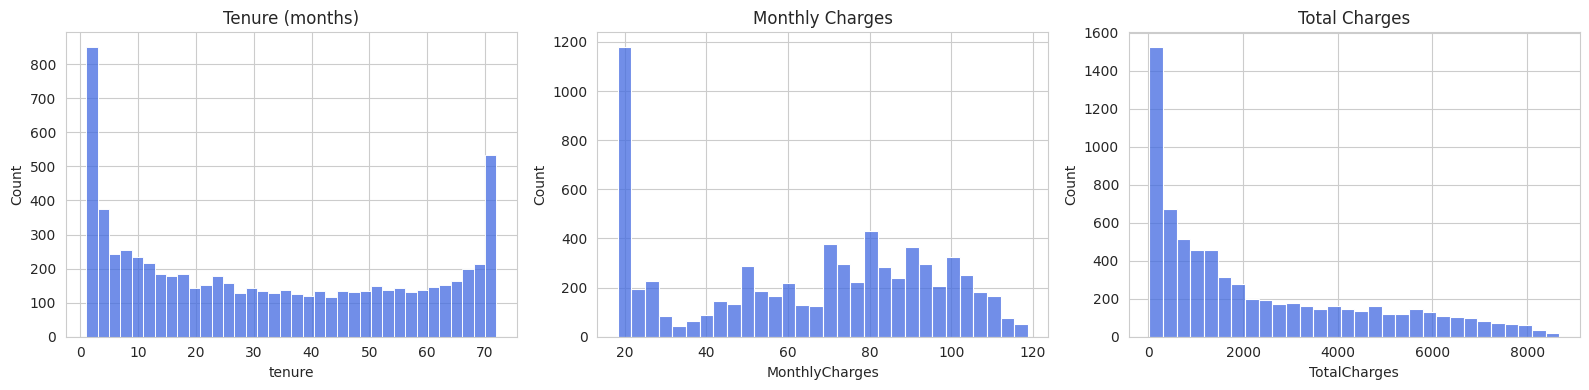

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['tenure'], bins=36, color='royalblue', ax=axes[0]).set_title('Tenure (months)')
sns.histplot(df['MonthlyCharges'], bins=30, color='royalblue', ax=axes[1]).set_title('Monthly Charges')
sns.histplot(df['TotalCharges'], bins=30, color='royalblue', ax=axes[2]).set_title('Total Charges')
plt.tight_layout()
plt.show()

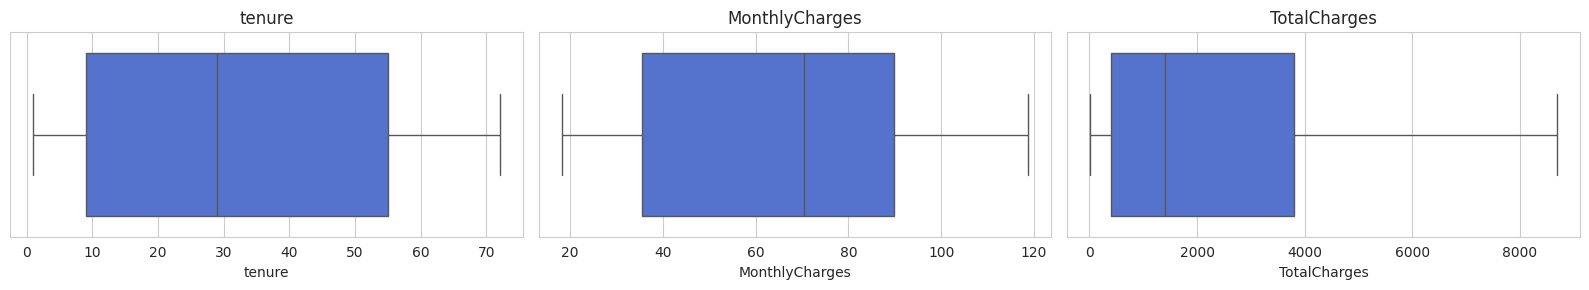

No meaningful outliers are present in the numerical features.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(x=df[col], ax=ax, color='royalblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()
print("No meaningful outliers are present in the numerical features.")

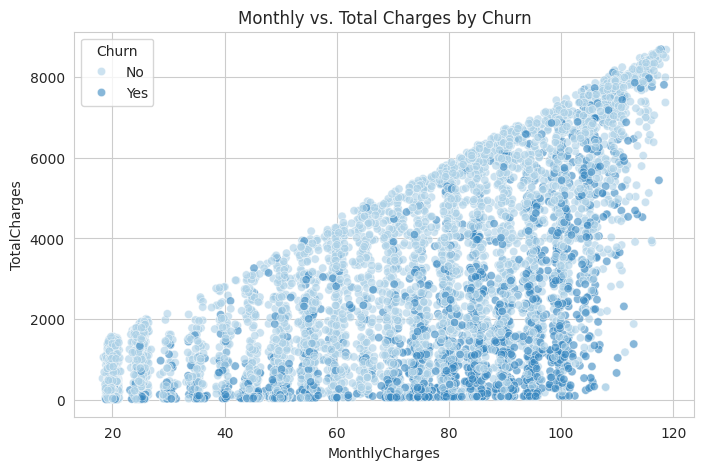

In [18]:
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', palette=PALETTE, alpha=0.6)
plt.title('Monthly vs. Total Charges by Churn')
plt.show()

Tenure shows a bimodal pattern — a spike of very new customers (1 month) and a spike of
long-tenured customers (~72 months). This is closely tied to contract type: month-to-month
customers churn quickly, while two-year contract customers stay much longer.

### 8.6 Churn vs. key drivers


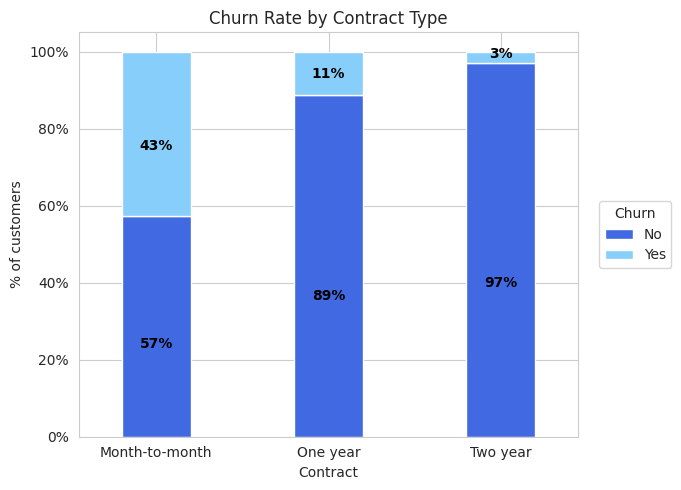

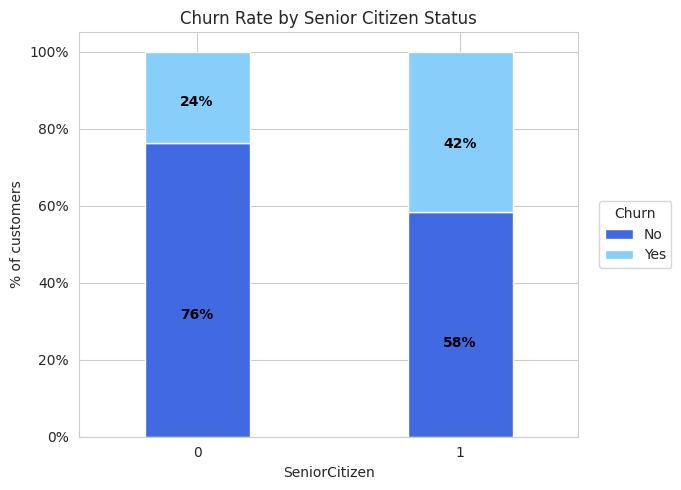

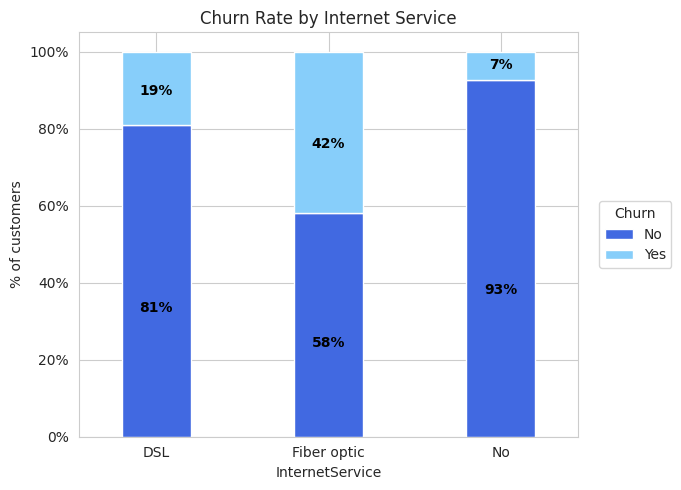

In [19]:
def stacked_pct_bar(groupby_cols, title, ax=None):
    tbl = df.groupby(groupby_cols).size().unstack()
    pct = (tbl.T * 100.0 / tbl.T.sum()).T
    ax = pct.plot(kind='bar', stacked=True, width=0.4, rot=0, figsize=(7, 5),
                  color=['royalblue', 'lightskyblue'], ax=ax)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel('% of customers')
    ax.set_title(title)
    ax.legend(title='Churn', bbox_to_anchor=(1.2, 0.5), loc='center right')
    for p in ax.patches:
        w, h = p.get_width(), p.get_height()
        if h > 0:
            ax.annotate(f'{h:.0f}%', (p.get_x() + 0.5 * w, p.get_y() + 0.4 * h),
                        ha='center', color='black', weight='bold')
    plt.tight_layout()
    plt.show()

stacked_pct_bar(['Contract', 'Churn'], 'Churn Rate by Contract Type')
stacked_pct_bar(['SeniorCitizen', 'Churn'], 'Churn Rate by Senior Citizen Status')
stacked_pct_bar(['InternetService', 'Churn'], 'Churn Rate by Internet Service')

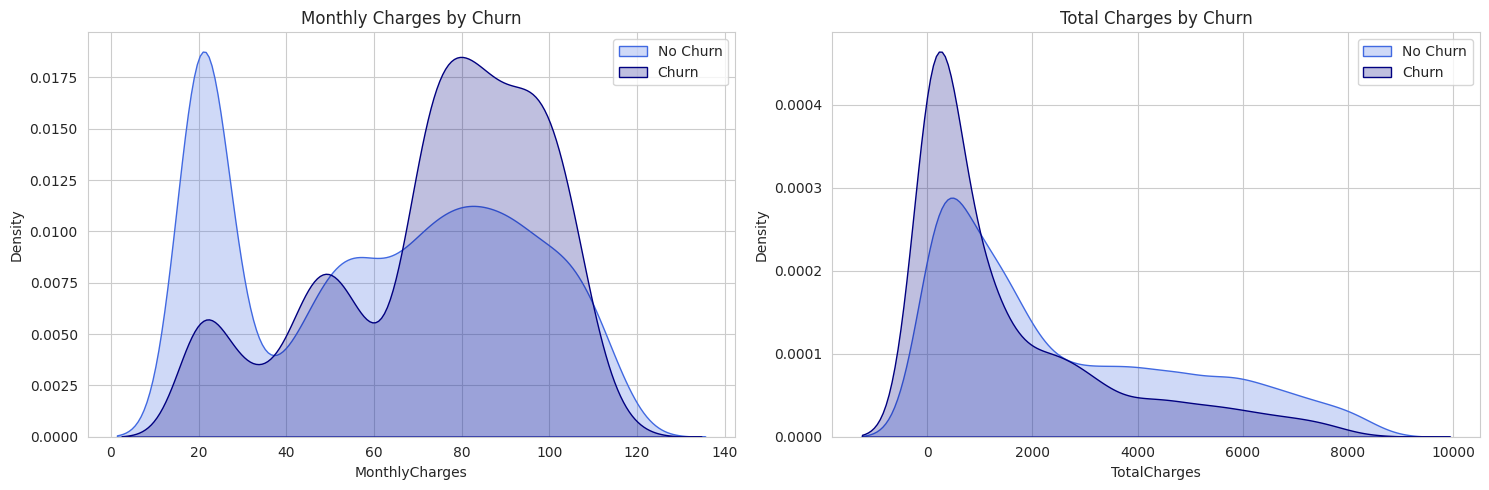

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(df.loc[df['Churn'] == 'No', 'MonthlyCharges'], fill=True, color='royalblue',
            label='No Churn', ax=axes[0])
sns.kdeplot(df.loc[df['Churn'] == 'Yes', 'MonthlyCharges'], fill=True, color='navy',
            label='Churn', ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
axes[0].legend()

sns.kdeplot(df.loc[df['Churn'] == 'No', 'TotalCharges'], fill=True, color='royalblue',
            label='No Churn', ax=axes[1])
sns.kdeplot(df.loc[df['Churn'] == 'Yes', 'TotalCharges'], fill=True, color='navy',
            label='Churn', ax=axes[1])
axes[1].set_title('Total Charges by Churn')
axes[1].legend()

plt.tight_layout()
plt.show()

Churners skew towards **higher monthly charges** and **lower total charges** (consistent
with shorter tenure — they leave before accumulating large total spend).

**Key EDA takeaways:**
- Month-to-month contracts and fiber-optic internet are strongly associated with churn.
- Customers without online security, tech support, device protection or online backup churn more.
- Senior citizens churn at a higher rate (42%) than non-seniors (24%).
- Higher monthly charges (roughly $70–110) correlate with a higher probability of churn.

### 8.7 Association / correlation analysis

To understand relationships between mixed categorical and numerical variables, we compute a
generalized association matrix: **Cramér's V** for categorical-categorical pairs, **correlation
ratio (η)** for categorical-numerical pairs, and **Spearman correlation** for numerical-numerical
pairs (Spearman is used instead of Pearson because tenure/charges are not normally distributed).


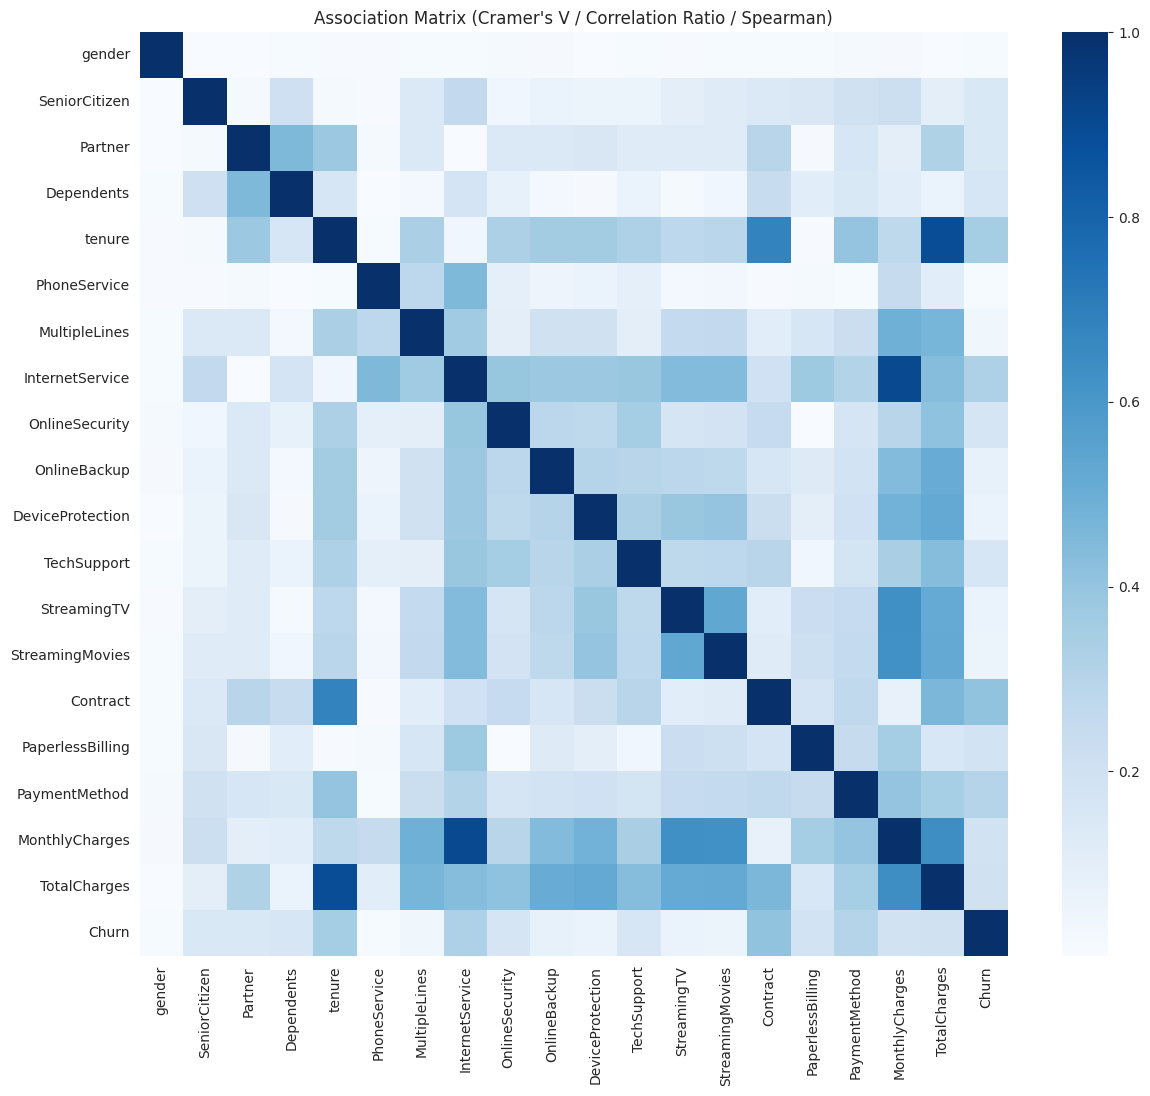

In [21]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    conf_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(conf_matrix)[0]
    n = conf_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = conf_matrix.shape
    return np.sqrt(phi2 / (min(r - 1, k - 1) + 1e-9))

def correlation_ratio(categories, values):
    categories = pd.factorize(categories)[0]
    cat_num = np.max(categories) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(cat_num):
        mask = categories == i
        n_array[i] = mask.sum()
        y_avg_array[i] = values[mask].mean() if mask.sum() > 0 else 0
    y_total_avg = values.mean()
    numerator = np.sum(n_array * (y_avg_array - y_total_avg) ** 2)
    denominator = np.sum((values - y_total_avg) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols]

assoc = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
for c1 in df.columns:
    for c2 in df.columns:
        if c1 == c2:
            assoc.loc[c1, c2] = 1.0
        elif c1 in num_cols and c2 in num_cols:
            assoc.loc[c1, c2] = abs(df[c1].corr(df[c2], method='spearman'))
        elif c1 in num_cols and c2 in cat_cols:
            assoc.loc[c1, c2] = correlation_ratio(df[c2], df[c1])
        elif c1 in cat_cols and c2 in num_cols:
            assoc.loc[c1, c2] = correlation_ratio(df[c1], df[c2])
        else:
            assoc.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(14, 12))
sns.heatmap(assoc.astype(float), cmap='Blues', annot=False)
plt.title("Association Matrix (Cramer's V / Correlation Ratio / Spearman)")
plt.show()

As expected, several service-related variables are correlated with each other (e.g. having
internet service is a prerequisite for online security, streaming, etc.), and `tenure` /
`TotalCharges` / `Contract` are related. Because the goal here is predictive power rather than
coefficient interpretation, this multicollinearity is noted but not treated as a blocker.


## 9. Feature Engineering

- **Encoding:** all categorical columns are one-hot encoded (`drop_first=True` to avoid the dummy
  variable trap).
- **Scaling:** the numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`) are scaled with
  `MinMaxScaler` so that tree-based and distance/gradient-based models are not biased by scale.


In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = MinMaxScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

df_encoded.head()

Shape after encoding: (7032, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,0.000000,0.115423,0.001275,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,0.464789,0.385075,0.215867,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,0.014085,0.354229,0.010310,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,0.619718,0.239303,0.210241,True,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0,0.014085,0.521891,0.015330,False,False,False,True,False,True,...,False,False,False,False,False,True,False,True,False,True


## 10. Train / Test Split

An 80/20 stratified split is used so that both sets preserve the ~26.5% churn rate.


In [23]:
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Train shape: (5625, 23), Test shape: (1407, 23)
Train churn rate: 0.266, Test churn rate: 0.266


## 11. Baseline Model Benchmarking

Rather than repeating near-identical code for each algorithm, a small evaluation helper is used to
train/score every candidate model consistently. Because this is a churn-retention problem, models
are ranked primarily by **recall** on the churn class (catching as many true churners as possible),
with precision, F1, and ROC-AUC reported alongside for context.


In [24]:
def evaluate_model(name, model, xtr, ytr, xte, yte, proba=True):
    model.fit(xtr, ytr)
    preds = model.predict(xte)

    if proba and hasattr(model, 'predict_proba'):
        scores = model.predict_proba(xte)[:, 1]
        auc = roc_auc_score(yte, scores)
    elif hasattr(model, 'decision_function'):
        scores = model.decision_function(xte)
        auc = roc_auc_score(yte, scores)
    else:
        auc = np.nan

    return {
        'model': name,
        'fitted_model': model,
        'train_accuracy': model.score(xtr, ytr),
        'test_accuracy': accuracy_score(yte, preds),
        'precision_churn': precision_score(yte, preds),
        'recall_churn': recall_score(yte, preds),
        'f1_churn': f1_score(yte, preds),
        'roc_auc': auc,
        'y_pred': preds,
    }

def build_model_zoo(random_state=RANDOM_STATE):
    return {
        'Ridge Classifier': RidgeClassifier(),
        'Logistic Regression': LogisticRegression(max_iter=2000, penalty='l2'),
        'Linear SVM': LinearSVC(max_iter=5000),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state),
        'Random Forest': RandomForestClassifier(random_state=random_state),
        'Gradient Boosting': GradientBoostingClassifier(random_state=random_state),
        'AdaBoost': AdaBoostClassifier(random_state=random_state),
        'XGBoost': XGBClassifier(random_state=random_state, eval_metric='logloss'),
        'Extra Trees': ExtraTreesClassifier(random_state=random_state),
        'Bagging': BaggingClassifier(random_state=random_state),
        'CatBoost': CatBoostClassifier(random_state=random_state, silent=True),
        'Voting (Ada+LR)': VotingClassifier(
            estimators=[('ada', AdaBoostClassifier(random_state=random_state)),
                        ('lr', LogisticRegression(max_iter=2000, penalty='l2'))],
            voting='soft'),
        'Stacking (Ada+LR)': StackingClassifier(
            estimators=[('ada', AdaBoostClassifier(random_state=random_state)),
                        ('lr', make_pipeline(LogisticRegression(max_iter=2000, penalty='l2')))]),
    }

def run_benchmark(xtr, ytr, xte, yte, random_state=RANDOM_STATE):
    zoo = build_model_zoo(random_state)
    results = []
    for name, model in zoo.items():
        results.append(evaluate_model(name, model, xtr, ytr, xte, yte))
    results_df = pd.DataFrame(results).sort_values(
        by=['recall_churn', 'f1_churn'], ascending=False
    ).reset_index(drop=True)
    return results_df

baseline_results = run_benchmark(x_train, y_train, x_test, y_test)
baseline_results.drop(columns=['fitted_model', 'y_pred'])

,model,train_accuracy,test_accuracy,precision_churn,recall_churn,f1_churn,roc_auc
0,Logistic Regression,0.808889,0.790334,0.635739,0.494652,0.556391,0.825410
1,Voting (Ada+LR),0.811911,0.791045,0.640845,0.486631,0.553191,0.829730
2,AdaBoost,0.811022,0.797441,0.663004,0.483957,0.559505,0.835486
3,Linear SVM,0.808000,0.787491,0.630662,0.483957,0.547655,0.822348
4,Stacking (Ada+LR),0.813867,0.790334,0.641577,0.478610,0.548239,0.831156
5,Gradient Boosting,0.828267,0.790334,0.645756,0.467914,0.542636,0.831498
6,Ridge Classifier,0.804622,0.788202,0.638686,0.467914,0.540123,0.816723
7,XGBoost,0.940622,0.786070,0.632727,0.465241,0.536210,0.814900
8,CatBoost,0.875378,0.785359,0.631387,0.462567,0.533951,0.827704
9,Decision Tree,0.998044,0.716418,0.466307,0.462567,0.464430,0.636267


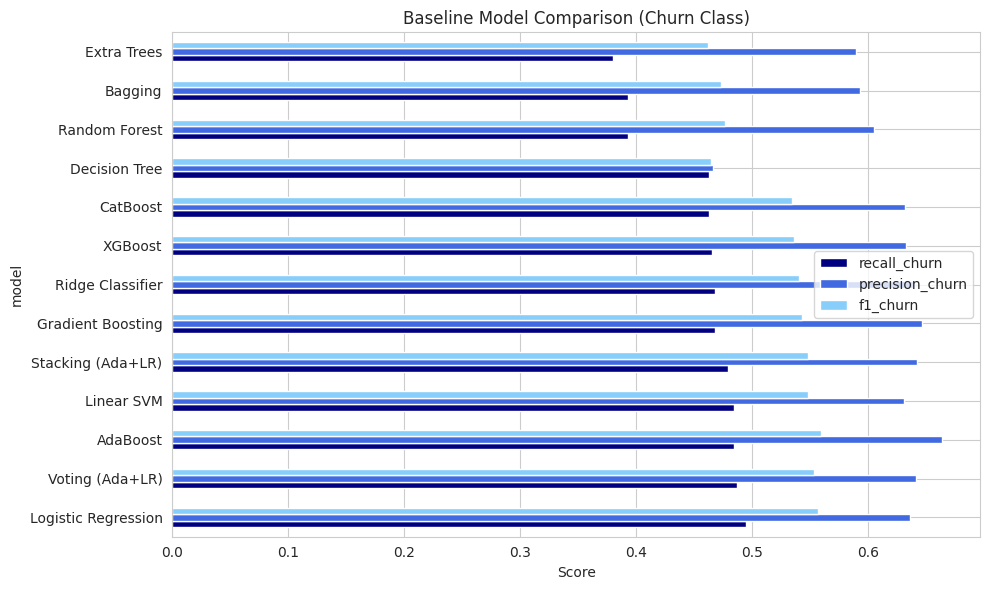

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = baseline_results.set_index('model')[['recall_churn', 'precision_churn', 'f1_churn']]
plot_df.plot(kind='barh', ax=ax, color=['navy', 'royalblue', 'lightskyblue'])
ax.set_title('Baseline Model Comparison (Churn Class)')
ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

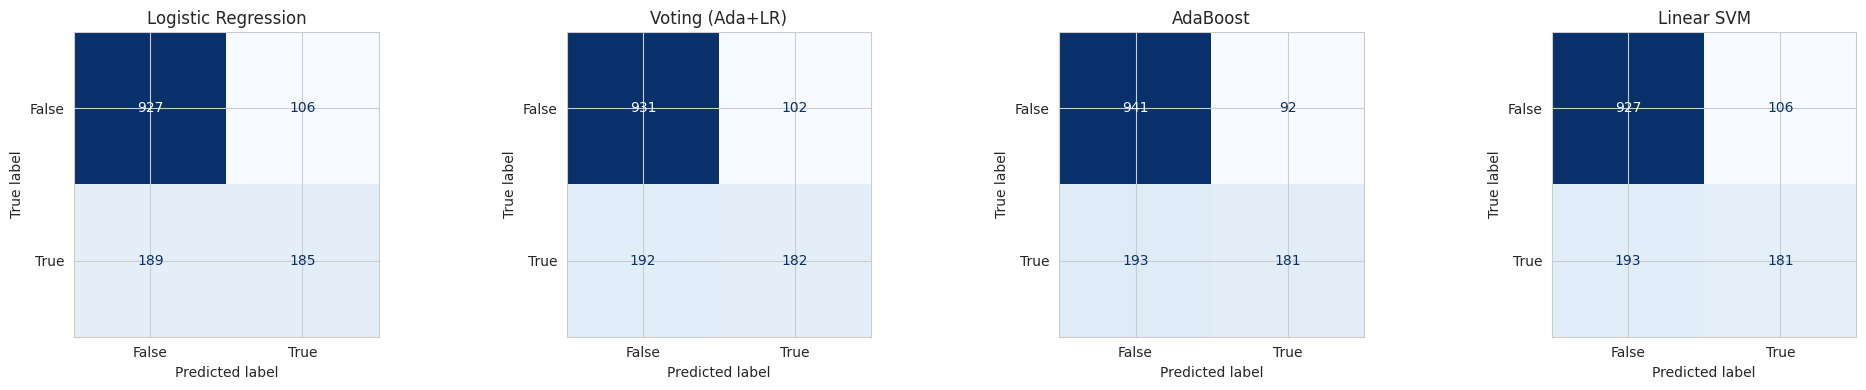

In [26]:
# Confusion matrices for the top 4 baseline models by recall
top4 = baseline_results.head(4)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (_, row) in zip(axes, top4.iterrows()):
    ConfusionMatrixDisplay.from_predictions(y_test, row['y_pred'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(row['model'])
plt.tight_layout()
plt.show()

**Observation:** the class imbalance (26.5% churn) causes most models to favor precision over
recall — they under-predict the minority (churn) class. The next section addresses this directly.


## 12. Handling Class Imbalance with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic examples of the
minority class (churners) so the model sees a balanced 50/50 class split during training. SMOTE is
applied **only to the training set** — the test set is left untouched so evaluation reflects
real-world class proportions.


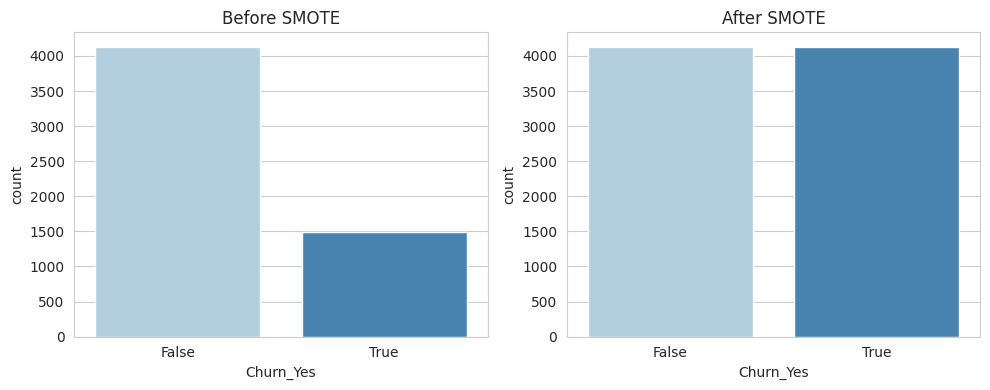

Train size before: 5625, after: 8260


In [27]:
smote = SMOTE(random_state=RANDOM_STATE)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train, palette=PALETTE, ax=axes[0]).set_title('Before SMOTE')
sns.countplot(x=y_train_sm, palette=PALETTE, ax=axes[1]).set_title('After SMOTE')
plt.tight_layout()
plt.show()
print(f"Train size before: {len(y_train)}, after: {len(y_train_sm)}")

In [28]:
smote_results = run_benchmark(x_train_sm, y_train_sm, x_test, y_test)
smote_results.drop(columns=['fitted_model', 'y_pred'])

,model,train_accuracy,test_accuracy,precision_churn,recall_churn,f1_churn,roc_auc
0,AdaBoost,0.785835,0.762615,0.540161,0.719251,0.616972,0.828641
1,Gradient Boosting,0.821671,0.762615,0.540323,0.716578,0.616092,0.828002
2,Voting (Ada+LR),0.792494,0.751955,0.524655,0.711230,0.603859,0.827147
3,Logistic Regression,0.792373,0.751244,0.523622,0.711230,0.603175,0.823588
4,Stacking (Ada+LR),0.793826,0.754087,0.528226,0.700535,0.602299,0.827680
5,Ridge Classifier,0.794794,0.751244,0.524096,0.697861,0.598624,0.818841
6,Linear SVM,0.803753,0.750533,0.523327,0.689840,0.595156,0.820282
7,CatBoost,0.894189,0.765458,0.551887,0.625668,0.586466,0.815711
8,XGBoost,0.943584,0.768301,0.558824,0.609626,0.583120,0.805091
9,Random Forest,0.998668,0.759062,0.544757,0.569519,0.556863,0.800265


In [29]:
comparison = baseline_results[['model', 'recall_churn', 'precision_churn', 'f1_churn']].merge(
    smote_results[['model', 'recall_churn', 'precision_churn', 'f1_churn']],
    on='model', suffixes=(' (baseline)', ' (SMOTE)')
)
comparison['recall_gain'] = comparison['recall_churn (SMOTE)'] - comparison['recall_churn (baseline)']
comparison.sort_values('recall_churn (SMOTE)', ascending=False).reset_index(drop=True)

,model,recall_churn (baseline),precision_churn (baseline),f1_churn (baseline),recall_churn (SMOTE),precision_churn (SMOTE),f1_churn (SMOTE),recall_gain
0,AdaBoost,0.483957,0.663004,0.559505,0.719251,0.540161,0.616972,0.235294
1,Gradient Boosting,0.467914,0.645756,0.542636,0.716578,0.540323,0.616092,0.248663
2,Logistic Regression,0.494652,0.635739,0.556391,0.711230,0.523622,0.603175,0.216578
3,Voting (Ada+LR),0.486631,0.640845,0.553191,0.711230,0.524655,0.603859,0.224599
4,Stacking (Ada+LR),0.478610,0.641577,0.548239,0.700535,0.528226,0.602299,0.221925
5,Ridge Classifier,0.467914,0.638686,0.540123,0.697861,0.524096,0.598624,0.229947
6,Linear SVM,0.483957,0.630662,0.547655,0.689840,0.523327,0.595156,0.205882
7,CatBoost,0.462567,0.631387,0.533951,0.625668,0.551887,0.586466,0.163102
8,XGBoost,0.465241,0.632727,0.536210,0.609626,0.558824,0.583120,0.144385
9,Random Forest,0.393048,0.604938,0.476499,0.569519,0.544757,0.556863,0.176471


SMOTE substantially improves recall on the churn class across almost every model, at some
cost to precision — an acceptable trade-off for a retention use case, where the cost of missing a
churner (lost revenue) generally outweighs the cost of a false alarm (an unnecessary retention
offer).

**Model selection:** the notebook proceeds with the SMOTE-trained model that has the best
recall/F1 balance, printed below.


Selected model: AdaBoost
              precision    recall  f1-score   support

       False       0.88      0.78      0.83      1033
        True       0.54      0.72      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.76      0.77      1407



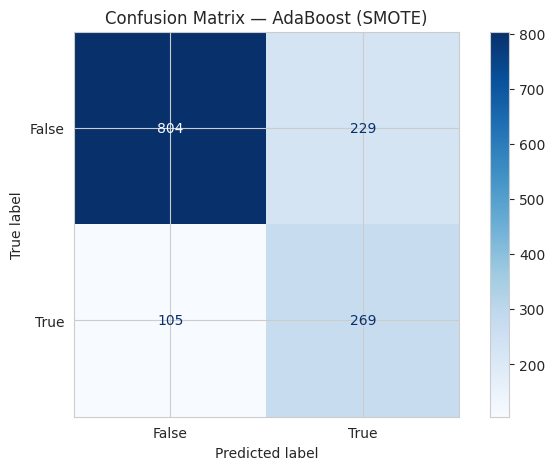

In [30]:
best_model_name = smote_results.sort_values(
    by=['recall_churn', 'f1_churn'], ascending=False
).iloc[0]['model']
best_row = smote_results[smote_results['model'] == best_model_name].iloc[0]
selected_model = best_row['fitted_model']

print(f"Selected model: {best_model_name}")
print(classification_report(y_test, best_row['y_pred']))
ConfusionMatrixDisplay.from_predictions(y_test, best_row['y_pred'], cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name} (SMOTE)')
plt.show()

## 13. Feature Importance

Understanding *why* the model predicts churn is as valuable to the business as the prediction
itself. Below, feature importance is inspected from a tree-based model (e.g. AdaBoost / Random
Forest) trained on the SMOTE-balanced data, and from Logistic Regression coefficients as an
interpretable baseline.


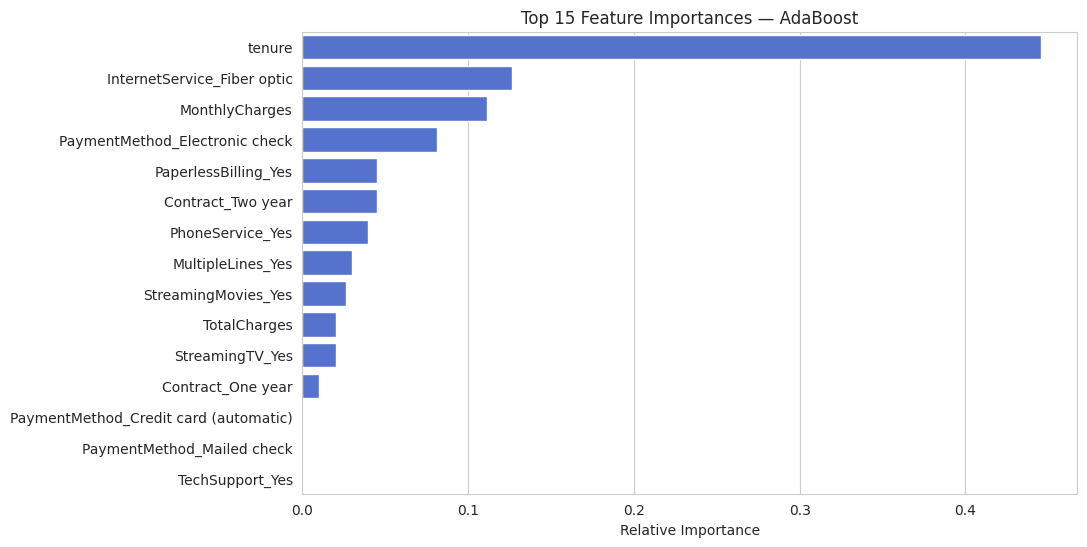

In [31]:
# Tree-based feature importance (works for AdaBoost, RandomForest, GradientBoosting, ExtraTrees, XGBoost, CatBoost)
if hasattr(selected_model, 'feature_importances_'):
    importances = selected_model.feature_importances_
    feat_names = x_train_sm.columns
    order = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[order], y=np.array(feat_names)[order], color='royalblue')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.xlabel('Relative Importance')
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_; "
          f"see the Logistic Regression coefficients below instead.")

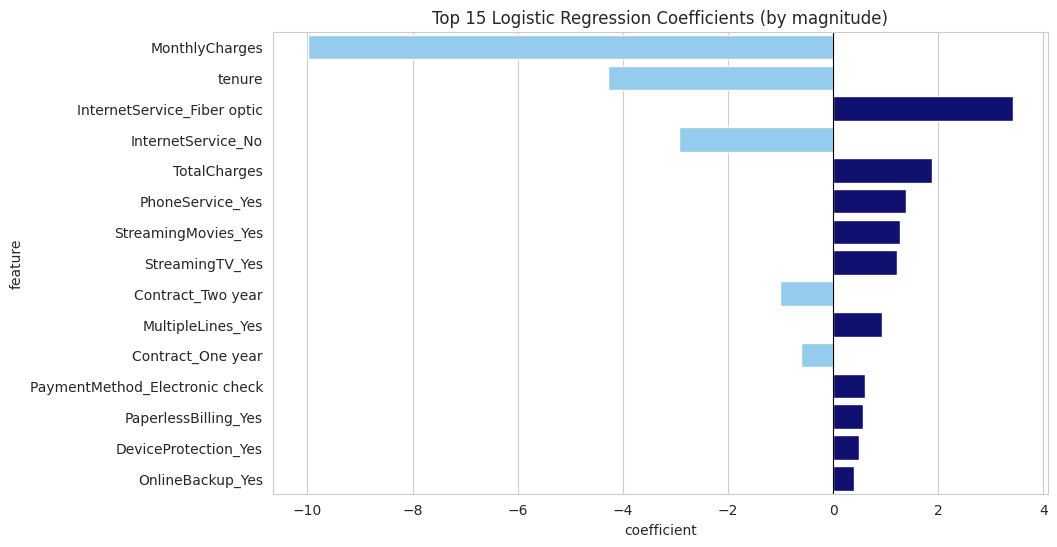

In [32]:
# Logistic Regression coefficients as an interpretable reference model
lr_ref = LogisticRegression(max_iter=2000, penalty='l2')
lr_ref.fit(x_train_sm, y_train_sm)

coef_df = pd.DataFrame({
    'feature': x_train_sm.columns,
    'coefficient': lr_ref.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature',
            palette=['navy' if c > 0 else 'lightskyblue' for c in coef_df['coefficient']])
plt.title('Top 15 Logistic Regression Coefficients (by magnitude)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

Positive coefficients push toward churn, negative coefficients push toward retention.
Consistently across both views, **contract length, tenure, fiber-optic internet, monthly charges,
and lack of tech support / online security** stand out as the strongest churn drivers — matching
the EDA findings.


## 14. Hyperparameter Tuning (Optuna)

The selected model is tuned with **Optuna**, a Bayesian hyperparameter optimization framework,
using 5-fold stratified cross-validation on the SMOTE-balanced training data. The search space
below is written generically for a boosting-style model (`AdaBoost`); adjust the parameter
grid if `run_benchmark` selected a different model on your run.


In [33]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 2.0)

    # Note: scikit-learn >= 1.4 removed the `algorithm` argument (SAMME.R was deprecated
    # and removed) -- only SAMME remains, so it no longer needs to be tuned.
    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=RANDOM_STATE,
    )
    scores = cross_val_score(
        model, x_train_sm, y_train_sm, scoring='recall',
        cv=StratifiedKFold(n_splits=5), n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print(f"Best CV recall: {study.best_trial.value:.4f}")
print(f"Best hyperparameters: {study.best_trial.params}")

Best CV recall: 0.8729
Best hyperparameters: {'n_estimators': 338, 'learning_rate': 0.015205256661833172}


train accuracy: 0.7699757869249395 
test accuracy: 0.7000710732054015
              precision    recall  f1-score   support

       False       0.91      0.66      0.76      1033
        True       0.46      0.82      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407



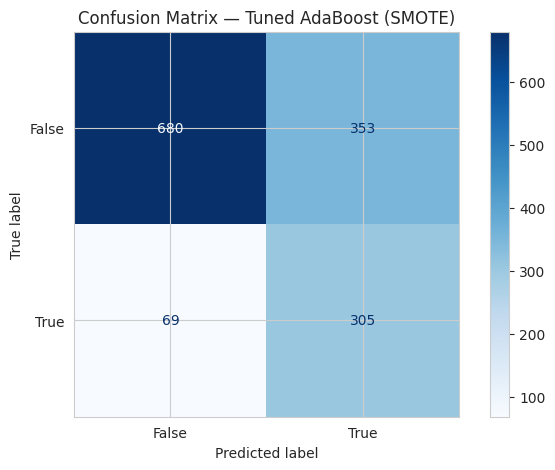

In [34]:
tuned_model = AdaBoostClassifier(**study.best_trial.params, random_state=RANDOM_STATE)
tuned_model.fit(x_train_sm, y_train_sm)
tuned_preds = tuned_model.predict(x_test)

print("train accuracy:", tuned_model.score(x_train_sm, y_train_sm),
      "\ntest accuracy:", tuned_model.score(x_test, y_test))
print(classification_report(y_test, tuned_preds))
ConfusionMatrixDisplay.from_predictions(y_test, tuned_preds, cmap='Blues')
plt.title('Confusion Matrix — Tuned AdaBoost (SMOTE)')
plt.show()

Compare the tuned model's recall/precision/F1 against the untuned `selected_model` from
Section 12 — keep whichever version performs better on the metric that matters most for the
business case (recall on churn).


## 15. Final Model Selection & Persistence

Pick the best-performing model from the sections above (baseline vs. SMOTE vs. tuned) based on
**recall** first, **F1** second, and save it to Google Drive so it can be reloaded for inference
without retraining.

> **Note on deep learning:** an AutoKeras neural-network benchmark was intentionally left out of
> this notebook. Current Colab environments only ship TensorFlow 2.16+ (Keras 3), and AutoKeras
> was built against the older Keras 2 API — the two are not compatible, and there's no longer a
> pip-installable TensorFlow 2.15 (or earlier) to pin around it. Given that gradient-boosted tree
> models like AdaBoost/XGBoost/CatBoost already perform strongly on this tabular dataset while
> being far cheaper to train and easier to explain to business stakeholders, this isn't a real
> loss for the project.


In [43]:
import joblib

# NOTE: point `final_model` at whichever model performed best in your run
final_model = tuned_model
final_model_name = "AdaBoost_SMOTE_Tuned"

SAVE_PATH = "/content/drive/MyDrive/Data Science & AI Projects/Project 2. Customer Churn Prediction/"
joblib.dump(final_model, SAVE_PATH + f"{final_model_name}.pkl")
joblib.dump(scaler, SAVE_PATH + "minmax_scaler.pkl")
print(f"Saved {final_model_name} and scaler to Drive.")

Saved AdaBoost_SMOTE_Tuned and scaler to Drive.


Final Model: AdaBoost_SMOTE_Tuned
              precision    recall  f1-score   support

       False       0.91      0.66      0.76      1033
        True       0.46      0.82      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407



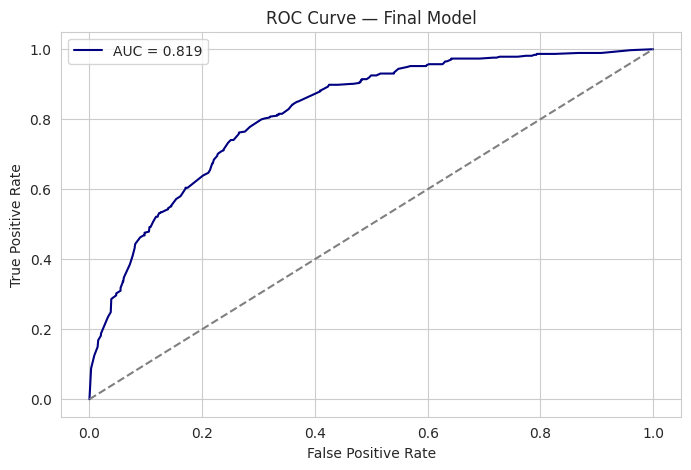

In [44]:
final_preds = final_model.predict(x_test)
final_probs = final_model.predict_proba(x_test)[:, 1] if hasattr(final_model, 'predict_proba') else None

print(f"Final Model: {final_model_name}")
print(classification_report(y_test, final_preds))

if final_probs is not None:
    fpr, tpr, _ = roc_curve(y_test, final_probs)
    auc_score = roc_auc_score(y_test, final_probs)
    plt.plot(fpr, tpr, color='navy', label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve — Final Model')
    plt.legend()
    plt.show()

## 16. Business Recommendations

Based on the EDA and modeling results:

1. **Target month-to-month customers early.** This segment has the highest churn rate by far.
   Consider incentivizing longer-term contracts (e.g. discounted pricing for 1–2 year commitments).
2. **Bundle protective services.** Customers without online security, tech support, device
   protection, or backup churn more — proactively offering these (or bundling them into a starter
   package) may reduce churn.
3. **Watch fiber-optic customers with high monthly charges ($70–110).** This combination shows an
   elevated churn probability; consider loyalty pricing or improved support for this segment.
4. **Prioritize senior citizens in retention campaigns** — they churn at nearly double the rate of
   non-seniors.
5. **Operationalize the model as an early-warning system:** score active customers monthly and
   route the highest-risk (highest predicted-probability) customers to a retention team, since the
   model is tuned to catch as many true churners as possible.

## 17. Limitations & Next Steps

- The dataset is a single snapshot in time; a production system should retrain periodically as
  customer behavior evolves.
- SMOTE creates synthetic examples in feature space — this is a reasonable mitigation for the
  class imbalance here, but should be validated against real-world churn as it is observed post
  deployment.
- Multicollinearity between service-related features means individual coefficients should be
  interpreted with caution; SHAP values would be a valuable follow-up for deeper explainability.
- Next steps: threshold tuning against a business-defined cost matrix (cost of a false negative vs.
  false positive), SHAP-based explainability, and A/B testing of retention interventions on the
  model's highest-risk segment.
